In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms.functional import resize
from PIL import Image 

class E3DLSTMCell(nn.Module):
    """E3D-LSTM Cell with 3D convolutions for spatiotemporal memory."""
    def __init__(self, in_channels, hidden_channels, kernel_size=(3, 3, 3)):
        super().__init__()
        self.hidden_channels = hidden_channels

        # Input modulation gates (3D convs)
        self.conv_xi = nn.Conv3d(in_channels, hidden_channels, kernel_size, padding=1)
        self.conv_hi = nn.Conv3d(hidden_channels, hidden_channels, kernel_size, padding=1, bias=False)
        
        # Forget gate
        self.conv_xf = nn.Conv3d(in_channels, hidden_channels, kernel_size, padding=1)
        self.conv_hf = nn.Conv3d(hidden_channels, hidden_channels, kernel_size, padding=1, bias=False)
        
        # Output gate
        self.conv_xo = nn.Conv3d(in_channels, hidden_channels, kernel_size, padding=1)
        self.conv_ho = nn.Conv3d(hidden_channels, hidden_channels, kernel_size, padding=1, bias=False)
        
        # Cell state
        self.conv_xc = nn.Conv3d(in_channels, hidden_channels, kernel_size, padding=1)
        self.conv_hc = nn.Conv3d(hidden_channels, hidden_channels, kernel_size, padding=1, bias=False)

    def forward(self, x, h_prev, c_prev):
        # x: (B, C, D, H, W), h_prev/c_prev: (B, hidden_channels, D, H, W)
        i = torch.sigmoid(self.conv_xi(x) + self.conv_hi(h_prev))
        f = torch.sigmoid(self.conv_xf(x) + self.conv_hf(h_prev))
        o = torch.sigmoid(self.conv_xo(x) + self.conv_ho(h_prev))
        c = f * c_prev + i * torch.tanh(self.conv_xc(x) + self.conv_hc(h_prev))
        h = o * torch.tanh(c)
        return h, c

class E3DLSTM(nn.Module):
    """2-layer E3D-LSTM for sequential processing."""
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.lstm1 = E3DLSTMCell(in_channels, hidden_channels)
        self.lstm2 = E3DLSTMCell(hidden_channels, hidden_channels)

    def forward(self, x):
        # x: (B, C, T, H, W)
        B, C, T, H, W = x.shape
        h1 = torch.zeros(B, self.lstm1.hidden_channels, T, H, W).to(x.device)
        c1 = torch.zeros(B, self.lstm1.hidden_channels, T, H, W).to(x.device)
        h2 = torch.zeros(B, self.lstm2.hidden_channels, T, H, W).to(x.device)
        c2 = torch.zeros(B, self.lstm2.hidden_channels, T, H, W).to(x.device)
        
        # Process all timesteps
        h1, c1 = self.lstm1(x, h1, c1)
        h2, c2 = self.lstm2(h1, h2, c2)
        
        return h2  # (B, hidden_channels, T, H, W)

import torch
import torch.nn as nn

class VideoPredictor(nn.Module):
    def __init__(self, C=3, D=64, T=10, H=256, W=256):
        super().__init__()
        self.T = T  # Number of input timesteps
        
        # Encoder (processes each frame independently)
        self.encoder = nn.Sequential(
            nn.Conv2d(C, D, kernel_size=3, padding=1, stride=2),  # H/2
            nn.ReLU(),
            nn.Conv2d(D, 2*D, kernel_size=3, padding=1, stride=2),  # H/4
            nn.ReLU(),
            nn.Conv2d(2*D, 4*D, kernel_size=3, padding=1, stride=2),  # H/8
            nn.ReLU(),
        )
        
        # E3D-LSTM (processes temporal sequence)
        self.e3d_lstm = E3DLSTM(4*D, 4*D)  # Uses the same E3DLSTM class as before
        
        # Predictive head (new - helps extrapolate future features)
        self.predictive_head = nn.Sequential(
            nn.Conv3d(4*D, 4*D, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.ReLU(),
        )
        
        # Decoder (reconstructs frame from features)
        self.decoder = nn.Sequential(
            nn.Conv2d(4*D, 2*D, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(2*D, D, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(D, C, kernel_size=3, padding=1),
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # x shape: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        
        # --- ENCODER ---
        # Process each input frame (excluding last frame if predicting beyond input)
        x_input = x[:, :-1]  # Use frames 0..T-1 to predict frame T
        encoded = self.encoder(x_input.reshape(B*(T-1), C, H, W))  # (B*(T-1), 4*D, H/8, W/8)
        encoded = encoded.reshape(B, T-1, *encoded.shape[1:]).permute(0, 2, 1, 3, 4)  # (B, 4*D, T-1, H/8, W/8)
        
        # --- TEMPORAL PROCESSING ---
        lstm_out = self.e3d_lstm(encoded)  # (B, 4*D, T-1, H/8, W/8)
        
        # --- FUTURE PREDICTION HEAD ---
        # Take last timestep features and extrapolate
        last_features = lstm_out[:, :, -1].unsqueeze(2)  # (B, 4*D, 1, H/8, W/8)
        future_features = self.predictive_head(last_features)  # (B, 4*D, 1, H/8, W/8)
        
        # --- DECODER ---
        pred = self.decoder(future_features.squeeze(2))  # (B, C, H, W)
        return pred
        
# Example Usage
model = VideoPredictor()
x = torch.randn(2, 10, 3, 256, 256)  # (B, T, C, H, W)
pred = model(x)
print("Prediction shape:", pred.shape)  # Should be (2, 3, 256, 256)

Prediction shape: torch.Size([2, 3, 256, 256])


In [5]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class VideoFrameDataset(Dataset):
    def __init__(self, root_dir, clip_length=10, transform=None):
        """
        Args:
            root_dir (string): Directory with video frames (each subdirectory = one video)
            clip_length (int): Number of frames in each input clip
            transform (callable, optional): Optional transform to be applied
        """
        self.root_dir = root_dir
        self.clip_length = clip_length
        self.transform = transform
        self.clips = []
        
        # Iterate through each video subdirectory
        for video_name in os.listdir(root_dir):
            video_dir = os.path.join(root_dir, video_name)
            if not os.path.isdir(video_dir):
                continue
                
            # Get sorted list of frame files
            frames = sorted([f for f in os.listdir(video_dir) if f.endswith(('.png', '.jpg'))])
            
            # Create clips of (clip_length input frames + 1 target frame)
            for i in range(len(frames) - clip_length):
                input_frames = frames[i:i+clip_length]
                target_frame = frames[i+clip_length]
                self.clips.append((
                    [os.path.join(video_dir, f) for f in input_frames],
                    os.path.join(video_dir, target_frame)
                ))

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        input_paths, target_path = self.clips[idx]
        
        # Load input frames
        input_frames = []
        for path in input_paths:
            img = Image.open(path)
            if self.transform:
                img = self.transform(img)
            img = np.array(img)
            input_frames.append(img)
        
        # Load target frame
        target_img = Image.open(target_path)
        if self.transform:
            target_img = self.transform(target_img)
        target_img = np.array(target_img)
        
        # Convert to tensors and normalize to [0, 1]
        input_frames = torch.stack([torch.FloatTensor(f) / 255.0 for f in input_frames])
        target_frame = torch.FloatTensor(target_img) / 255.0
        
        # Permute dimensions: (T, H, W, C) → (T, C, H, W)
        if input_frames.dim() == 4:  # If frames have channels (e.g., RGB)
            input_frames = input_frames.permute(0, 3, 1, 2)
            target_frame = target_frame.permute(2, 0, 1)
        
        return input_frames, target_frame

In [7]:
#from model import VideoPredictor  # Your 2D CNN + E3D-LSTM model
import torch.optim as optim

# Hyperparameters
BATCH_SIZE = 2
CLIP_LENGTH = 2
LR = 1e-4
EPOCHS = 100

# Initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VideoPredictor(C=3, D=64, T=CLIP_LENGTH, H=256, W=256).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM
from torch.utils.data import DataLoader

class VideoPredictionLoss(nn.Module):
    def __init__(self, alpha=1, beta=1, gamma=1):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.ssim = SSIM(data_range=1.0)
        
    def forward(self, pred, target, prev_frame=None):
        mse_loss = F.mse_loss(pred, target)
        ssim_loss = 1 - self.ssim(pred, target)
        
        # Initialize flow_loss as tensor to ensure .item() exists
        flow_loss = torch.tensor(0.0, device=pred.device)
        if prev_frame is not None:
            flow_diff = pred - prev_frame - (target - prev_frame)
            flow_loss = torch.mean(torch.sqrt(flow_diff**2 + 1e-6))
            
        total_loss = (self.alpha * mse_loss + 
                     self.beta * ssim_loss + 
                     self.gamma * flow_loss)
        
        return total_loss, {'mse': mse_loss.item(), 
                          'ssim': ssim_loss.item(),
                          'flow': flow_loss.item()}  # Now safe to call .item()

def train_and_validate(model, train_loader, val_loader, epochs, device):
    writer = SummaryWriter()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)
    loss_fn = VideoPredictionLoss().to(device)
    
    best_val_loss = float('inf')
    val_losses = []  # Track validation losses for min() comparison
    
    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_loss = 0.0
        train_metrics = {'mse': 0.0, 'ssim': 0.0, 'flow': 0.0}
        
        for batch_idx, (clip_sequence, _) in enumerate(train_loader):
            # Training forward pass
            inputs = clip_sequence[:, :-1].to(device)
            target = clip_sequence[:, -1].to(device)
            prev_frame = clip_sequence[:, -2].to(device)
            
            optimizer.zero_grad()
            pred = model(inputs)
            loss, metrics = loss_fn(pred, target, prev_frame)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            train_loss += loss.item()
            for k in metrics:
                train_metrics[k] += metrics[k]
            
            if batch_idx % 10 == 0:
                writer.add_scalar('Loss/train_batch', loss.item(), epoch*len(train_loader)+batch_idx)
                writer.add_scalars('Metrics/train_batch', metrics, epoch*len(train_loader)+batch_idx)
        
        # Validation Phase
        model.eval()
        val_loss = 0.0
        val_metrics = {'mse': 0.0, 'ssim': 0.0}
        
        with torch.no_grad():
            for val_idx, (val_sequence, _) in enumerate(val_loader):
                val_inputs = val_sequence[:, :-1].to(device)
                val_target = val_sequence[:, -1].to(device)
                
                # Correct validation forward pass
                val_pred = model(val_inputs)
                loss, metrics = loss_fn(val_pred, val_target, prev_frame=None)
                
                val_loss += loss.item()
                val_metrics['mse'] += metrics['mse']
                val_metrics['ssim'] += metrics['ssim']
        
        # Calculate epoch averages
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        avg_train_metrics = {k: v/len(train_loader) for k,v in train_metrics.items()}
        avg_val_metrics = {k: v/len(val_loader) for k,v in val_metrics.items()}
        
        # Logging
        writer.add_scalar('Loss/train', avg_train_loss, epoch)
        writer.add_scalar('Loss/val', avg_val_loss, epoch)
        writer.add_scalars('Metrics/train', avg_train_metrics, epoch)
        writer.add_scalars('Metrics/val', avg_val_metrics, epoch)
        
        # Learning rate scheduling
        scheduler.step(avg_val_loss)
        
        # Save best model
        if avg_val_loss == min(val_losses):
            torch.save(model.state_dict(), "best_model.pth")
        
        # Print epoch summary
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"Train MSE: {avg_train_metrics['mse']:.4f} | Val MSE: {avg_val_metrics['mse']:.4f}")
        print(f"Train SSIM: {avg_train_metrics['ssim']:.4f} | Val SSIM: {avg_val_metrics['ssim']:.4f}")
        print(f"Train Flow: {avg_train_metrics['flow']:.4f}")
        print("-" * 60)
    
    writer.close()

# Initialize model and dataloaders
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VideoPredictor().to(device)

train_dataset = VideoFrameDataset(
    root_dir=r"C:\Users\Shaswata\Desktop\Datasets\Videopredictor\train",
    clip_length=CLIP_LENGTH + 1
)
val_dataset = VideoFrameDataset(
    root_dir=r"C:\Users\Shaswata\Desktop\Datasets\Videopredictor\valid",
    clip_length=CLIP_LENGTH + 1
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Start training
train_and_validate(model, train_loader, val_loader, EPOCHS, device)


Epoch 1/100
Train Loss: 0.7984 | Val Loss: 0.5835
Train MSE: 0.0353 | Val MSE: 0.0153
Train SSIM: 0.6215 | Val SSIM: 0.5682
Train Flow: 0.1416
------------------------------------------------------------

Epoch 2/100
Train Loss: 0.6111 | Val Loss: 0.5160
Train MSE: 0.0139 | Val MSE: 0.0101
Train SSIM: 0.5175 | Val SSIM: 0.5060
Train Flow: 0.0797
------------------------------------------------------------

Epoch 3/100
Train Loss: 0.5445 | Val Loss: 0.4897
Train MSE: 0.0091 | Val MSE: 0.0085
Train SSIM: 0.4723 | Val SSIM: 0.4812
Train Flow: 0.0630
------------------------------------------------------------

Epoch 4/100
Train Loss: 0.5180 | Val Loss: 0.4744
Train MSE: 0.0082 | Val MSE: 0.0079
Train SSIM: 0.4513 | Val SSIM: 0.4665
Train Flow: 0.0586
------------------------------------------------------------

Epoch 5/100
Train Loss: 0.5013 | Val Loss: 0.4629
Train MSE: 0.0078 | Val MSE: 0.0075
Train SSIM: 0.4366 | Val SSIM: 0.4555
Train Flow: 0.0569
------------------------------------

KeyboardInterrupt: 

In [9]:
import torch
import torch.nn as nn
#from your_model_file import VideoPredictor  # Import your model class

def load_pretrained_model(model_path, device=None):
    """
    Load a pretrained model with proper error handling and device management
    
    Args:
        model_path: Path to .pth file
        device: 'cuda', 'cpu', or None (auto-detect)
    
    Returns:
        Loaded model in evaluation mode
    """
    # Device configuration
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # 1. Initialize your model architecture (must match saved model)
    model = VideoPredictor()  # Use same parameters as during training
    
    try:
        # 2. Load the state dict
        checkpoint = torch.load(model_path, map_location=device)
        
        # 3. Handle different save formats
        if isinstance(checkpoint, nn.Module):
            # If entire model was saved
            model = checkpoint
        elif 'state_dict' in checkpoint:
            # If checkpoint dict was saved
            model.load_state_dict(checkpoint['state_dict'])
        else:
            # If only state_dict was saved
            model.load_state_dict(checkpoint)
        
        # 4. Set to evaluation mode and move to device
        model = model.to(device)
        model.eval()
        
        print(f"Successfully loaded model from {model_path}")
        print(f"Model device: {next(model.parameters()).device}")
        return model
        
    except Exception as e:
        print(f"Error loading model from {model_path}: {str(e)}")
        raise

# Usage example
if __name__ == "__main__":
    # Path to your saved model
    MODEL_PATH = "best_model_finetuned.pth"  
    
    model = load_pretrained_model(MODEL_PATH)
        
       

Successfully loaded model from best_model_finetuned.pth
Model device: cpu


C:\Users\Shaswata\AppData\Local\Temp\ipykernel_57948\2149410381.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)

In [35]:
# Load validation data (normal and anomalous)
CLIP_LENGTH = 2
from torch.utils.data import DataLoader
val_dataset_normal = VideoFrameDataset(root_dir=r"C:\Users\Shaswata\Desktop\Datasets\Avenue\nor", clip_length=CLIP_LENGTH)
val_dataset_anomalous = VideoFrameDataset(root_dir=r"C:\Users\Shaswata\Desktop\Datasets\Avenue\Abnormal\original", clip_length=CLIP_LENGTH)

val_loader_normal = DataLoader(val_dataset_normal, batch_size=BATCH_SIZE)
val_loader_anomalous = DataLoader(val_dataset_anomalous, batch_size=BATCH_SIZE)

# Compute reconstruction errors
def evaluate(loader, model, device):
    model.eval()
    errors = []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            preds = model(inputs)
            error = F.mse_loss(preds, targets, reduction='none').mean(dim=(1, 2, 3))
            errors.extend(error.cpu().numpy())
    return np.array(errors)

# Get errors
normal_errors = evaluate(val_loader_normal, model, device)
anomalous_errors = evaluate(val_loader_anomalous, model, device)

# Set anomaly threshold (e.g., 95th percentile of normal errors)
threshold = np.percentile(normal_errors, 95)
print(f"Anomaly Threshold: {threshold:.4f}")

# Classify anomalies
y_true = np.concatenate([np.zeros_like(normal_errors), np.ones_like(anomalous_errors)])
y_scores = np.concatenate([normal_errors, anomalous_errors])
y_pred = (y_scores > threshold).astype(int)

# Compute metrics
from sklearn.metrics import roc_auc_score, f1_score
auc = roc_auc_score(y_true, y_scores)
f1 = f1_score(y_true, y_pred)
print(f"AUC: {auc:.4f} | F1: {f1:.4f}")

Anomaly Threshold: 0.0353
AUC: 0.9031 | F1: 0.3073


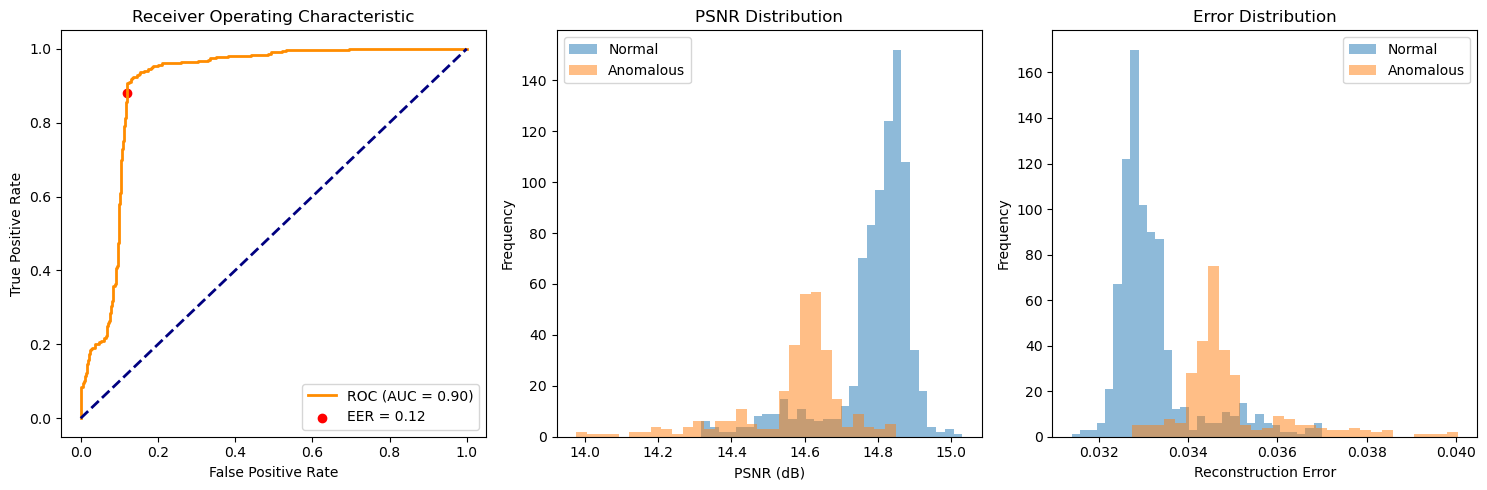


=== Comprehensive Anomaly Detection Metrics ===
Anomaly Threshold (MSE): 0.0353
Anomaly Threshold (PSNR): 14.52 dB
ROC AUC: 0.9031
Equal Error Rate: 0.1208 (Threshold: 0.0341)
F1 Score: 0.3073
Normal PSNR: 14.79 ± 0.11 dB
Anomalous PSNR: 14.57 ± 0.15 dB


In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as roc_auc
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import numpy as np

# ... [Previous code remains the same until metrics calculation] ...

# 1. Enhanced Metrics Calculation
def calculate_psnr(mse):
    return 10 * np.log10(1.0 / mse) if mse > 0 else 100

psnr_normal = np.array([calculate_psnr(e) for e in normal_errors])
psnr_anomalous = np.array([calculate_psnr(e) for e in anomalous_errors])

# 2. ROC Curve Analysis
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = roc_auc_score(y_true, y_scores)

# 3. Equal Error Rate Calculation
def calculate_eer(fpr, tpr):
    """Returns Equal Error Rate and threshold"""
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    threshold = interp1d(fpr, thresholds)(eer)
    return eer, threshold

eer, eer_threshold = calculate_eer(fpr, tpr)

# 4. Plotting
plt.figure(figsize=(15, 5))

# ROC Curve
plt.subplot(1, 3, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.scatter(fpr[np.argmin(np.abs(tpr - (1 - fpr)))], 
            1 - fpr[np.argmin(np.abs(tpr - (1 - fpr)))],
            color='red', label=f'EER = {eer:.2f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")

# PSNR Distribution
plt.subplot(1, 3, 2)
plt.hist(psnr_normal, bins=30, alpha=0.5, label='Normal')
plt.hist(psnr_anomalous, bins=30, alpha=0.5, label='Anomalous')
#plt.axvline(calculate_psnr(threshold), color='r', linestyle='--', 
            #label=f'Threshold: {calculate_psnr(threshold):.1f} dB')
plt.xlabel('PSNR (dB)')
plt.ylabel('Frequency')
plt.title('PSNR Distribution')
plt.legend()

# Error Distribution
plt.subplot(1, 3, 3)
plt.hist(normal_errors, bins=30, alpha=0.5, label='Normal')
plt.hist(anomalous_errors, bins=30, alpha=0.5, label='Anomalous')
#plt.axvline(threshold, color='r', linestyle='--', 
            #label=f'Threshold: {threshold:.4f}')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.title('Error Distribution')
plt.legend()

plt.tight_layout()
plt.savefig('anomaly_detection_metrics.png', dpi=800)
plt.show()

# Print comprehensive metrics
print("\n=== Comprehensive Anomaly Detection Metrics ===")
print(f"Anomaly Threshold (MSE): {threshold:.4f}")
print(f"Anomaly Threshold (PSNR): {calculate_psnr(threshold):.2f} dB")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Equal Error Rate: {eer:.4f} (Threshold: {eer_threshold:.4f})")
print(f"F1 Score: {f1:.4f}")
print(f"Normal PSNR: {np.mean(psnr_normal):.2f} ± {np.std(psnr_normal):.2f} dB")
print(f"Anomalous PSNR: {np.mean(psnr_anomalous):.2f} ± {np.std(psnr_anomalous):.2f} dB")

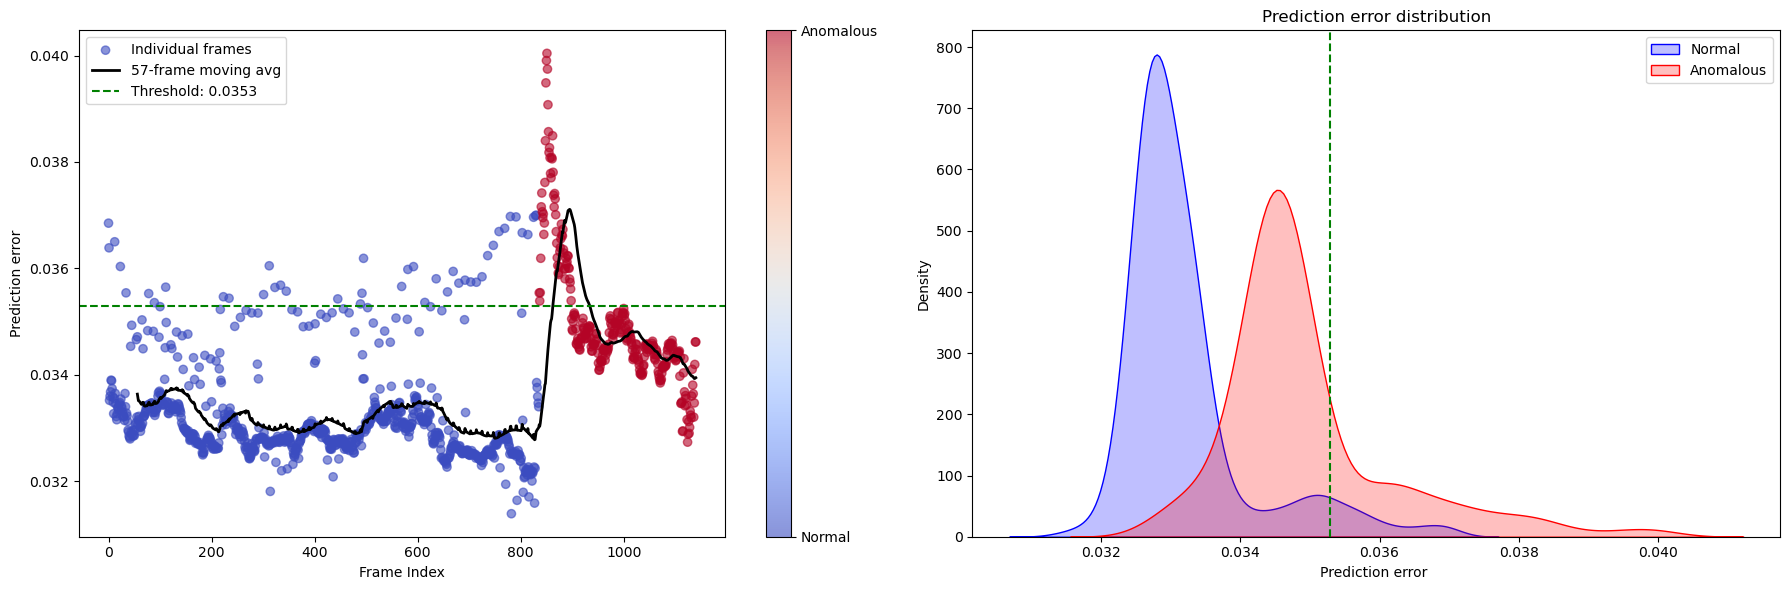


=== Frame-wise Anomaly Statistics ===
Normal Frames:    Mean = 0.0332 ± 0.0009
Anomalous Frames: Mean = 0.0350 ± 0.0012
Threshold:        0.0353 (95th %ile of Normal)
Classification:   75.1% accurate


In [55]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_anomaly_scores(normal_errors, anomalous_errors, threshold):
    """Plot frame-wise anomaly scores with proper formatting"""
    # Convert labels to integers for proper palette mapping
    all_scores = np.concatenate([normal_errors, anomalous_errors])
    labels = np.concatenate([np.zeros_like(normal_errors, dtype=int), 
                           np.ones_like(anomalous_errors, dtype=int)])
    
    # Create frame-wise visualization
    plt.figure(figsize=(18, 6))
    
    # 1. Frame-by-frame scores with rolling average
    plt.subplot(1, 2, 1)
    x_values = np.arange(len(all_scores))
    
    # Plot individual frames
    scatter = plt.scatter(x_values, all_scores, c=labels, 
                         cmap='coolwarm', alpha=0.6, 
                         label='Individual frames')
    
    # Add rolling average for trend
    window_size = max(1, len(all_scores)//20)  # Adaptive window size
    rolling_avg = np.convolve(all_scores, np.ones(window_size)/window_size, mode='valid')
    plt.plot(x_values[window_size-1:], rolling_avg, 
             'k-', linewidth=2, label=f'{window_size}-frame moving avg')
    
    plt.axhline(threshold, color='g', linestyle='--', 
                label=f'Threshold: {threshold:.4f}')
    plt.xlabel('Frame Index')
    plt.ylabel('Prediction error')
    #plt.title('Frae')
    plt.legend()
    
    # Create colorbar for classes
    cbar = plt.colorbar(scatter, ticks=[0, 1])
    cbar.ax.set_yticklabels(['Normal', 'Anomalous'])
    
    # 2. Distribution plot
    plt.subplot(1, 2, 2)
    sns.kdeplot(normal_errors, color='blue', label='Normal', fill=True)
    sns.kdeplot(anomalous_errors, color='red', label='Anomalous', fill=True)
    plt.axvline(threshold, color='g', linestyle='--')
    plt.xlabel('Prediction error ')
    plt.ylabel('Density')
    plt.title('Prediction error distribution')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('frame_wise_anomaly_scores.png', dpi=800, bbox_inches='tight')
    plt.show()
    
    # Print statistics
    print("\n=== Frame-wise Anomaly Statistics ===")
    print(f"Normal Frames:    Mean = {np.mean(normal_errors):.4f} ± {np.std(normal_errors):.4f}")
    print(f"Anomalous Frames: Mean = {np.mean(anomalous_errors):.4f} ± {np.std(anomalous_errors):.4f}")
    print(f"Threshold:        {threshold:.4f} (95th %ile of Normal)")
    print(f"Classification:   {100*(1 - (np.sum(normal_errors > threshold) + np.sum(anomalous_errors <= threshold))/len(all_scores)):.1f}% accurate")

# Usage
plot_anomaly_scores(normal_errors, anomalous_errors, threshold)

Anomaly Threshold (PSNR): 14.55 dB


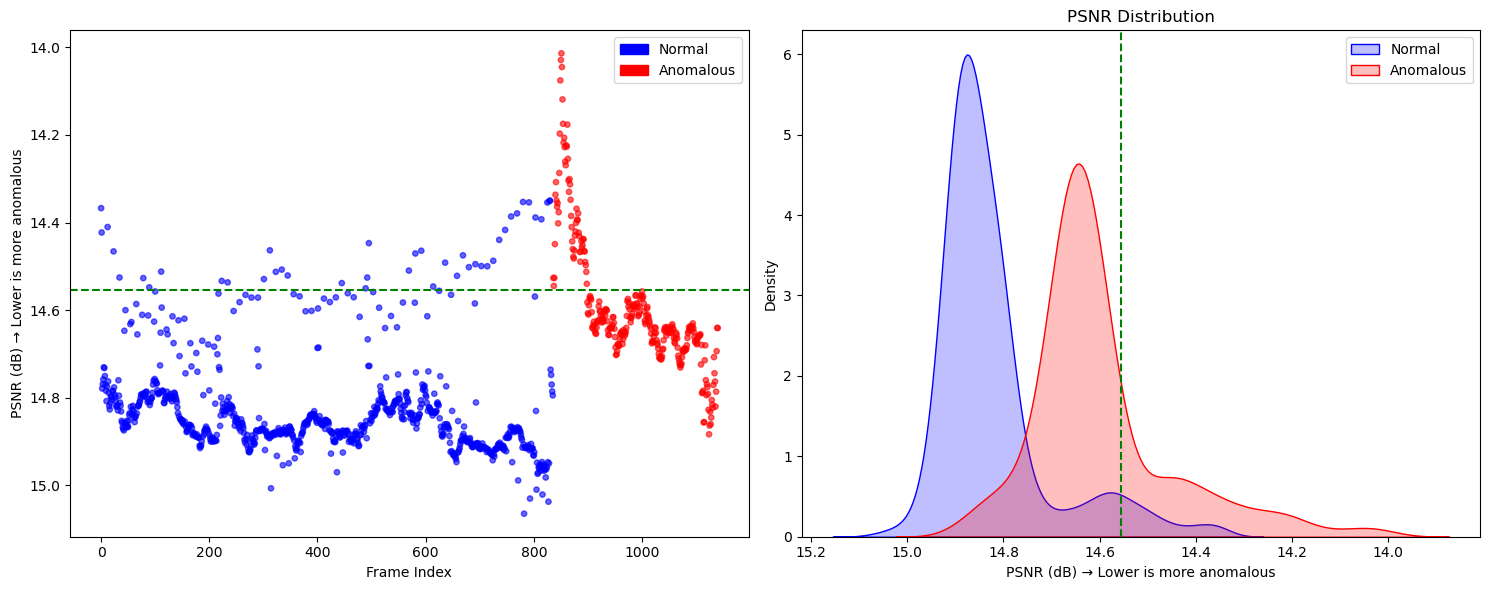


=== PSNR Anomaly Detection Statistics ===
Normal Frames:    Mean PSNR = 14.82 ± 0.12 dB
Anomalous Frames: Mean PSNR = 14.60 ± 0.15 dB
Threshold:        14.55 dB (5th %ile of Normal)
Classification:   75.1% accurate

ROC AUC: 0.9042
F1 Score: 0.3073


In [59]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.metrics import peak_signal_noise_ratio

def calculate_psnr(target, prediction):
    """Calculate PSNR between target and prediction frames"""
    # Convert to [0,255] range if needed
    if target.max() <= 1.0:
        target = (target * 255).astype(np.uint8)
        prediction = (prediction * 255).astype(np.uint8)
    return peak_signal_noise_ratio(target, prediction, data_range=255)

def evaluate_psnr(loader, model, device):
    """Calculate PSNR scores for a data loader"""
    model.eval()
    psnr_scores = []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            preds = model(inputs)
            
            # Calculate PSNR for each sample in batch
            for i in range(preds.shape[0]):
                psnr = calculate_psnr(targets[i].cpu().numpy(), 
                                     preds[i].cpu().numpy())
                psnr_scores.append(psnr)
    return np.array(psnr_scores)

# Calculate PSNR scores
normal_psnr = evaluate_psnr(val_loader_normal, model, device)
anomalous_psnr = evaluate_psnr(val_loader_anomalous, model, device)

# Set threshold (5th percentile of normal PSNR)
threshold = np.percentile(normal_psnr, 5)  # Lower PSNR = more anomalous
print(f"Anomaly Threshold (PSNR): {threshold:.2f} dB")

def plot_psnr_scores(normal_psnr, anomalous_psnr, threshold):
    """Plot PSNR-based anomaly scores"""
    plt.figure(figsize=(15, 6))
    
    # Combine all scores
    all_psnr = np.concatenate([normal_psnr, anomalous_psnr])
    labels = np.concatenate([np.zeros_like(normal_psnr), 
                            np.ones_like(anomalous_psnr)])
    
    # 1. Frame-wise PSNR values
    plt.subplot(1, 2, 1)
    x_values = np.arange(len(all_psnr))
    colors = ['blue' if label == 0 else 'red' for label in labels]
    
    plt.scatter(x_values, all_psnr, c=colors, alpha=0.6, s=15)
    plt.axhline(threshold, color='green', linestyle='--', 
                label=f'Threshold: {threshold:.2f} dB')
    plt.gca().invert_yaxis()  # Lower PSNR at top = more anomalous
    plt.xlabel('Frame Index')
    plt.ylabel('PSNR (dB) → Lower is more anomalous')
    #plt.title('Frame-wise Anomaly Scores (PSNR)')
    
    # Add color legend
    import matplotlib.patches as mpatches
    blue_patch = mpatches.Patch(color='blue', label='Normal')
    red_patch = mpatches.Patch(color='red', label='Anomalous')
    plt.legend(handles=[blue_patch, red_patch])
    
    # 2. Distribution plot
    plt.subplot(1, 2, 2)
    sns.kdeplot(normal_psnr, color='blue', label='Normal', fill=True)
    sns.kdeplot(anomalous_psnr, color='red', label='Anomalous', fill=True)
    plt.axvline(threshold, color='green', linestyle='--')
    plt.gca().invert_xaxis()  # Lower PSNR at right = more anomalous
    plt.xlabel('PSNR (dB) → Lower is more anomalous')
    plt.ylabel('Density')
    plt.title('PSNR Distribution')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('psnr_anomaly_scores.png', dpi=800, bbox_inches='tight')
    plt.show()

    # Print statistics
    print("\n=== PSNR Anomaly Detection Statistics ===")
    print(f"Normal Frames:    Mean PSNR = {np.mean(normal_psnr):.2f} ± {np.std(normal_psnr):.2f} dB")
    print(f"Anomalous Frames: Mean PSNR = {np.mean(anomalous_psnr):.2f} ± {np.std(anomalous_psnr):.2f} dB")
    print(f"Threshold:        {threshold:.2f} dB (5th %ile of Normal)")
    print(f"Classification:   {100*(1 - (np.sum(normal_psnr < threshold) + np.sum(anomalous_psnr >= threshold))/len(all_psnr)):.1f}% accurate")

# Generate plots
plot_psnr_scores(normal_psnr, anomalous_psnr, threshold)

# Calculate metrics
y_true = np.concatenate([np.zeros_like(normal_psnr), np.ones_like(anomalous_psnr)])
y_scores = -np.concatenate([normal_psnr, anomalous_psnr])  # Negative PSNR for proper ROC (lower PSNR = more anomalous)

from sklearn.metrics import roc_auc_score, f1_score
threshold_preds = (np.concatenate([normal_psnr, anomalous_psnr]) < threshold).astype(int)
print(f"\nROC AUC: {roc_auc_score(y_true, y_scores):.4f}")
print(f"F1 Score: {f1_score(y_true, threshold_preds):.4f}")

In [27]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from tqdm import tqdm

def save_comparison_frames(model, normal_loader, abnormal_loader, output_dir="comparison_frames", device='cuda'):
    """
    Saves frame-by-frame comparison visualizations without displaying them.
    
    Args:
        model: Trained model
        normal_loader: Dataloader for normal sequences
        abnormal_loader: Dataloader for abnormal sequences
        output_dir: Output directory for frames
        device: Device to run inference on
    """
    model.eval()
    os.makedirs(output_dir, exist_ok=True)
    
    def process_sequence(loader, loader_type):
        seq_dir = os.path.join(output_dir, loader_type)
        os.makedirs(seq_dir, exist_ok=True)
        
        with torch.no_grad():
            for batch_idx, (inputs, targets) in enumerate(tqdm(loader, desc=f'Processing {loader_type} sequences')):
                inputs, targets = inputs.to(device), targets.to(device)
                preds = model(inputs)
                
                # Convert to numpy and ensure correct shape
                inputs_np = inputs.cpu().numpy()
                targets_np = targets.cpu().numpy()
                preds_np = preds.cpu().numpy()
                
                # Ensure we have batch dimension
                if inputs_np.ndim == 4:  # If batch dimension is missing
                    inputs_np = np.expand_dims(inputs_np, axis=0)
                    targets_np = np.expand_dims(targets_np, axis=0)
                    preds_np = np.expand_dims(preds_np, axis=0)
                
                # Process each frame in sequence
                for t in range(inputs_np.shape[1]):
                    # Prepare frames
                    input_frame = inputs_np[0, t]
                    target_frame = targets_np[0, t]
                    pred_frame = preds_np[0, t]
                    
                    # Create figure without displaying
                    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
                    fig.suptitle(f'Frame {t+1}/{inputs_np.shape[1]} - {loader_type.capitalize()}')
                    
                    # Input frame
                    if input_frame.shape[0] == 1:  # Grayscale
                        axes[0, 0].imshow(input_frame[0], cmap='gray', vmin=0, vmax=1)
                    else:  # RGB
                        axes[0, 0].imshow(np.moveaxis(input_frame, 0, -1), vmin=0, vmax=1)
                    axes[0, 0].set_title('Input Frame')
                    axes[0, 0].axis('off')
                    
                    # Ground truth
                    if target_frame.shape[0] == 1:  # Grayscale
                        axes[0, 1].imshow(target_frame[0], cmap='gray', vmin=0, vmax=1)
                    else:  # RGB
                        axes[0, 1].imshow(np.moveaxis(target_frame, 0, -1), vmin=0, vmax=1)
                    axes[0, 1].set_title('Ground Truth')
                    axes[0, 1].axis('off')
                    
                    # Prediction
                    if pred_frame.shape[0] == 1:  # Grayscale
                        axes[1, 0].imshow(pred_frame[0], cmap='gray', vmin=0, vmax=1)
                    else:  # RGB
                        axes[1, 0].imshow(np.moveaxis(pred_frame, 0, -1), vmin=0, vmax=1)
                    axes[1, 0].set_title('Prediction')
                    axes[1, 0].axis('off')
                    
                    # Error map - ensure it's 2D
                    error = np.abs(target_frame - pred_frame)
                    if error.ndim == 3:  # If RGB
                        error = error.mean(axis=0)  # Convert to grayscale
                    elif error.ndim == 2:  # If already grayscale
                        pass
                    else:
                        error = error[0]  # Take first channel if unexpected shape
                    
                    im = axes[1, 1].imshow(error, cmap='hot', vmin=0, vmax=0.5)
                    plt.colorbar(im, ax=axes[1, 1])
                    axes[1, 1].set_title('Error Map')
                    axes[1, 1].axis('off')
                    
                    # Save figure
                    frame_path = os.path.join(seq_dir, f'seq_{batch_idx}_frame_{t:04d}.png')
                    plt.savefig(frame_path, dpi=100, bbox_inches='tight')
                    plt.close(fig)
    
    # Process both normal and abnormal sequences
    process_sequence(normal_loader, 'normal')
    process_sequence(abnormal_loader, 'abnormal')
    
    print(f"All frames saved to {output_dir}")

# Usage example
save_comparison_frames(
    model=model,
    normal_loader=val_loader_normal,
    abnormal_loader=val_loader_anomalous,
    device=device
)

Processing abnormal sequences: 100%|██████████| 142/142 [02:39<00:00,  1.12s/it]

All frames saved to comparison_frames


Processing normal sequences:  15%|█▌        | 85/564 [01:52<10:34,  1.32s/it]


KeyboardInterrupt: 

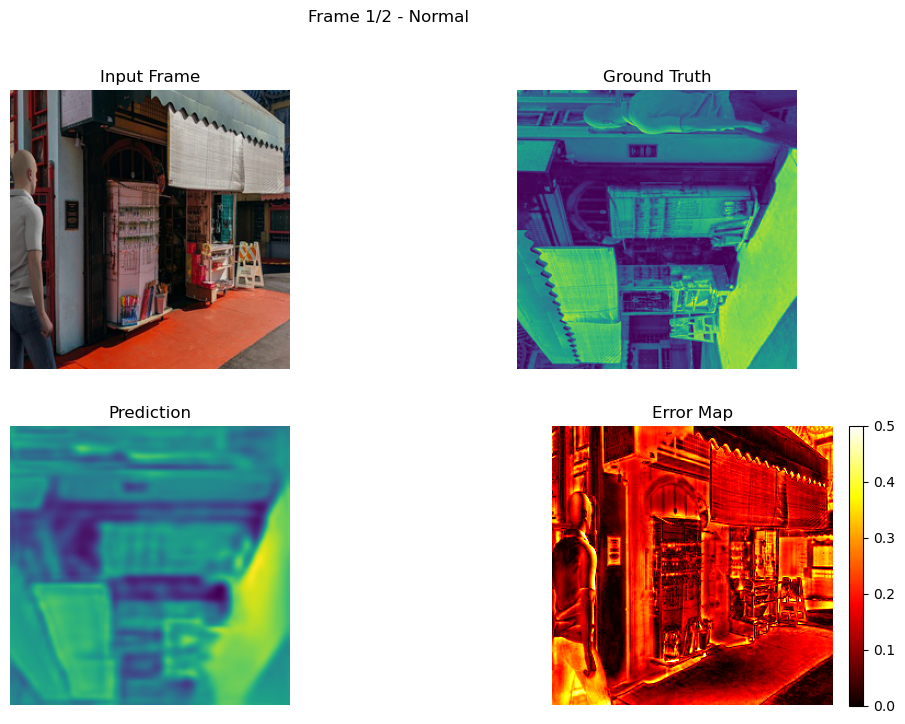

In [29]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from tqdm import tqdm

def save_comparison_frames(model, normal_loader, abnormal_loader, output_dir="comparison_frames", device='cuda'):
    """
    Saves frame-by-frame comparison visualizations with proper RGB display and orientation.
    
    Args:
        model: Trained model
        normal_loader: Dataloader for normal sequences
        abnormal_loader: Dataloader for abnormal sequences
        output_dir: Output directory for frames
        device: Device to run inference on
    """
    model.eval()
    os.makedirs(output_dir, exist_ok=True)
    
    def process_sequence(loader, loader_type):
        seq_dir = os.path.join(output_dir, loader_type)
        os.makedirs(seq_dir, exist_ok=True)
        
        with torch.no_grad():
            for batch_idx, (inputs, targets) in enumerate(tqdm(loader, desc=f'Processing {loader_type} sequences')):
                inputs, targets = inputs.to(device), targets.to(device)
                preds = model(inputs)
                
                # Convert to numpy and ensure correct shape (B, T, C, H, W)
                inputs_np = inputs.cpu().numpy()
                targets_np = targets.cpu().numpy()
                preds_np = preds.cpu().numpy()
                
                # Ensure we have batch dimension
                if inputs_np.ndim == 4:  # If batch dimension is missing
                    inputs_np = np.expand_dims(inputs_np, axis=0)
                    targets_np = np.expand_dims(targets_np, axis=0)
                    preds_np = np.expand_dims(preds_np, axis=0)
                
                # Process each frame in sequence
                for t in range(inputs_np.shape[1]):
                    # Get frames (C, H, W)
                    input_frame = inputs_np[0, t]
                    target_frame = targets_np[0, t]
                    pred_frame = preds_np[0, t]
                    
                    # Create figure without displaying
                    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
                    fig.suptitle(f'Frame {t+1}/{inputs_np.shape[1]} - {loader_type.capitalize()}')
                    
                    # Convert all frames to RGB format (H, W, 3)
                    def prepare_rgb(frame):
                        if frame.shape[0] == 1:  # Grayscale to RGB
                            frame = np.repeat(frame, 3, axis=0)
                        return np.moveaxis(frame, 0, -1)  # CHW to HWC
                    
                    # Input frame (always show as RGB)
                    input_rgb = prepare_rgb(input_frame)
                    axes[0, 0].imshow(np.clip(input_rgb, 0, 1))
                    axes[0, 0].set_title('Input Frame')
                    axes[0, 0].axis('off')
                    
                    # Ground truth (always show as RGB)
                    target_rgb = prepare_rgb(target_frame)
                    axes[0, 1].imshow(np.clip(target_rgb, 0, 1))
                    axes[0, 1].set_title('Ground Truth')
                    axes[0, 1].axis('off')
                    
                    # Prediction (always show as RGB)
                    pred_rgb = prepare_rgb(pred_frame)
                    axes[1, 0].imshow(np.clip(pred_rgb, 0, 1))
                    axes[1, 0].set_title('Prediction')
                    axes[1, 0].axis('off')
                    
                    # Error map (grayscale heatmap)
                    error = np.abs(target_frame - pred_frame)
                    if error.ndim == 3:  # RGB
                        error = error.mean(axis=0)  # Convert to grayscale
                    elif error.ndim == 2:  # Grayscale
                        pass
                    else:
                        error = error[0]  # Take first channel if unexpected shape
                    
                    im = axes[1, 1].imshow(error, cmap='hot', vmin=0, vmax=0.5)
                    plt.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)
                    axes[1, 1].set_title('Error Map')
                    axes[1, 1].axis('off')
                    
                    # Save figure
                    frame_path = os.path.join(seq_dir, f'seq_{batch_idx}_frame_{t:04d}.png')
                    plt.savefig(frame_path, dpi=100, bbox_inches='tight')
                    plt.close(fig)
    
    # Process both normal and abnormal sequences
    process_sequence(normal_loader, 'normal')
    process_sequence(abnormal_loader, 'abnormal')
    
    print(f"All frames saved to {output_dir}")

# Usage example
save_comparison_frames(
    model=model,
    normal_loader=val_loader_normal,
    abnormal_loader=val_loader_anomalous,
    device=device
)

In [31]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from tqdm import tqdm

def generate_comparison_visualizations(model, normal_loader, abnormal_loader, output_dir="comparison_visualizations", device='cuda'):
    """
    Generates frame-by-frame comparison visualizations for normal and abnormal data.
    
    Args:
        model: Trained model
        normal_loader: Dataloader for normal sequences
        abnormal_loader: Dataloader for abnormal sequences
        output_dir: Output directory for visualizations
        device: Device to run inference on
    """
    model.eval()
    os.makedirs(output_dir, exist_ok=True)
    
    # Process both normal and abnormal data
    for loader_type, loader in [('normal', normal_loader), ('abnormal', abnormal_loader)]:
        loader_dir = os.path.join(output_dir, loader_type)
        os.makedirs(loader_dir, exist_ok=True)
        
        with torch.no_grad():
            for batch_idx, (inputs, targets) in enumerate(tqdm(loader, desc=f'Processing {loader_type} sequences')):
                inputs, targets = inputs.to(device), targets.to(device)
                preds = model(inputs)
                
                # Convert to numpy for visualization
                inputs_np = inputs.cpu().numpy()
                targets_np = targets.cpu().numpy()
                preds_np = preds.cpu().numpy()
                
                # Ensure we have batch dimension
                if inputs_np.ndim == 4:  # If batch dimension is missing
                    inputs_np = np.expand_dims(inputs_np, axis=0)
                    targets_np = np.expand_dims(targets_np, axis=0)
                    preds_np = np.expand_dims(preds_np, axis=0)
                
                # Calculate PSNR for each frame
                psnr_scores = []
                for t in range(targets_np.shape[1]):  # For each frame in sequence
                    # Handle both grayscale and RGB cases
                    target_frame = targets_np[0, t]
                    pred_frame = preds_np[0, t]
                    
                    if target_frame.shape[0] == 1:  # Grayscale
                        target_frame = target_frame[0]  # Remove channel dimension
                        pred_frame = pred_frame[0]
                    else:  # RGB
                        target_frame = np.moveaxis(target_frame, 0, -1)  # CHW to HWC
                        pred_frame = np.moveaxis(pred_frame, 0, -1)
                    
                    psnr_scores.append(psnr(target_frame, pred_frame, data_range=1.0))
                
                # Create visualization for each frame in sequence
                for t in range(inputs_np.shape[1]):  # For each frame in sequence
                    fig = plt.figure(figsize=(18, 8))
                    gs = fig.add_gridspec(2, 3)
                    
                    # Get and prepare frames
                    input_frame = inputs_np[0, t]
                    target_frame = targets_np[0, t]
                    pred_frame = preds_np[0, t]
                    
                    # Handle different channel formats
                    if input_frame.shape[0] == 1:  # Grayscale
                        input_frame = input_frame[0]  # Remove channel dimension
                        target_frame = target_frame[0]
                        pred_frame = pred_frame[0]
                        
                        # Current input frame
                        ax1 = fig.add_subplot(gs[0, 0])
                        ax1.imshow(input_frame, cmap='gray', vmin=0, vmax=1)
                        ax1.set_title(f'Input Frame {t+1}/{inputs_np.shape[1]}')
                        ax1.axis('off')
                        
                        # Ground Truth
                        ax2 = fig.add_subplot(gs[0, 1])
                        ax2.imshow(target_frame, cmap='gray', vmin=0, vmax=1)
                        ax2.set_title('Ground Truth')
                        ax2.axis('off')
                        
                        # Prediction
                        ax3 = fig.add_subplot(gs[0, 2])
                        ax3.imshow(pred_frame, cmap='gray', vmin=0, vmax=1)
                        ax3.set_title(f'Prediction (PSNR: {psnr_scores[t]:.2f} dB)')
                        ax3.axis('off')
                        
                    else:  # RGB
                        input_frame = np.moveaxis(input_frame, 0, -1)
                        target_frame = np.moveaxis(target_frame, 0, -1)
                        pred_frame = np.moveaxis(pred_frame, 0, -1)
                        
                        # Current input frame
                        ax1 = fig.add_subplot(gs[0, 0])
                        ax1.imshow(np.clip(input_frame, 0, 1))
                        ax1.set_title(f'Input Frame {t+1}/{inputs_np.shape[1]}')
                        ax1.axis('off')
                        
                        # Ground Truth
                        ax2 = fig.add_subplot(gs[0, 1])
                        ax2.imshow(np.clip(target_frame, 0, 1))
                        ax2.set_title('Ground Truth')
                        ax2.axis('off')
                        
                        # Prediction
                        ax3 = fig.add_subplot(gs[0, 2])
                        ax3.imshow(np.clip(pred_frame, 0, 1))
                        ax3.set_title(f'Prediction (PSNR: {psnr_scores[t]:.2f} dB)')
                        ax3.axis('off')
                    
                    # Absolute Error (works for both grayscale and RGB)
                    error_frame = np.abs(targets_np[0, t] - preds_np[0, t])
                    if error_frame.ndim == 3:  # RGB
                        error_frame = error_frame.mean(axis=0)  # Convert to grayscale
                    else:  # Grayscale
                        error_frame = error_frame[0] if error_frame.shape[0] == 1 else error_frame
                    
                    ax4 = fig.add_subplot(gs[1, 0])
                    error_img = ax4.imshow(error_frame, cmap='hot', vmin=0, vmax=0.5)
                    plt.colorbar(error_img, ax=ax4, fraction=0.046, pad=0.04)
                    ax4.set_title('Absolute Error')
                    ax4.axis('off')
                    
                    # PSNR Trend
                    ax5 = fig.add_subplot(gs[1, 1:])
                    ax5.plot(psnr_scores[:t+1], 'b-', label='Frame PSNR')
                    ax5.axhline(np.mean(psnr_scores[:t+1]), color='r', linestyle='--', label='Mean PSNR')
                    ax5.set_xlim(0, len(psnr_scores))
                    ax5.set_ylim(10, 50)  # Adjust based on your PSNR range
                    ax5.set_xlabel('Frame Index')
                    ax5.set_ylabel('PSNR (dB)')
                    ax5.set_title('PSNR Trend')
                    ax5.legend()
                    ax5.grid(True)
                    
                    plt.tight_layout()
                    
                    # Save frame
                    frame_path = os.path.join(loader_dir, f'seq_{batch_idx}_frame_{t:04d}.png')
                    plt.savefig(frame_path, dpi=120, bbox_inches='tight')
                    plt.close()
                
                # Create video from frames
                create_video_from_frames(loader_dir, batch_idx)
    
    print(f"Visualizations saved to {output_dir}")

def create_video_from_frames(frame_dir, seq_idx):
    """Helper function to create video from saved frames"""
    frame_files = sorted([f for f in os.listdir(frame_dir) if f.startswith(f'seq_{seq_idx}_frame_') and f.endswith('.png')])
    if not frame_files:
        return
    
    # Determine frame size from first image
    first_frame = cv2.imread(os.path.join(frame_dir, frame_files[0]))
    if first_frame is None:
        print(f"Failed to read first frame in {frame_dir}")
        return
    
    height, width = first_frame.shape[:2]
    
    video_path = os.path.join(frame_dir, f'sequence_{seq_idx}.mp4')
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    fps = 5  # Adjust as needed
    video_writer = cv2.VideoWriter(video_path, fourcc, fps, (width, height))
    
    for frame_file in frame_files:
        frame = cv2.imread(os.path.join(frame_dir, frame_file))
        if frame is not None:
            video_writer.write(frame)
        else:
            print(f"Failed to read frame: {frame_file}")
    
    video_writer.release()
    print(f"Saved video to {video_path}")

# Usage example
generate_comparison_visualizations(
    model=model,
    normal_loader=val_loader_normal,
    abnormal_loader=val_loader_anomalous,
    device=device
)

Processing normal sequences:   0%|          | 1/564 [00:02<20:17,  2.16s/it]

Saved video to comparison_visualizations\normal\sequence_0.mp4


Processing normal sequences:   0%|          | 2/564 [00:06<31:40,  3.38s/it]

Saved video to comparison_visualizations\normal\sequence_1.mp4


Processing normal sequences:   1%|          | 3/564 [00:08<26:20,  2.82s/it]

...

Saved video to comparison_visualizations\abnormal\sequence_139.mp4


Processing abnormal sequences:  99%|█████████▉| 141/142 [05:15<00:02,  2.18s/it]

Saved video to comparison_visualizations\abnormal\sequence_140.mp4


Processing abnormal sequences: 100%|██████████| 142/142 [05:17<00:00,  2.24s/it]

Saved video to comparison_visualizations\abnormal\sequence_141.mp4
Visualizations saved to comparison_visualizations


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions(model, dataloader, num_examples=3, device='cuda'):
    """
    Visualizes model predictions with error maps and saves to files.
    
    Args:
        model: Trained model
        dataloader: Test/validation dataloader
        num_examples: Number of examples to visualize
        device: Device to run inference on
    """
    model.eval()
    examples = []
    
    # Create output directory
    output_dir = "prediction_visualizations"
    os.makedirs(output_dir, exist_ok=True)
    
    # Get sample batches
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(dataloader):
            inputs, targets = inputs.to(device), targets.to(device)
            preds = model(inputs)
            
            # Convert to numpy for visualization
            inputs_np = inputs.cpu().numpy()
            targets_np = targets.cpu().numpy()
            preds_np = preds.cpu().numpy()
            
            # Calculate error maps
            errors = np.abs(targets_np - preds_np)
            errors = np.mean(errors, axis=1)  # Combine RGB channels
            
            # Process each example in batch
            for i in range(inputs.shape[0]):
                if len(examples) >= num_examples:
                    break
                    
                example = {
                    'input_frames': inputs_np[i],
                    'prediction': preds_np[i],
                    'target': targets_np[i],
                    'error_map': errors[i]
                }
                examples.append(example)
                
                # Create visualization for this example
                fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))
                
                # Show input frames (first, middle, last)
                input_frames = example['input_frames']
                key_frames = [0, len(input_frames)//2, -1]  # First, middle, last
                
                # Display input frames in first subplot
                input_display = np.hstack([
                    np.transpose(input_frames[frame_idx], (1, 2, 0)) 
                    for frame_idx in key_frames
                ])
                ax1.imshow(np.clip(input_display, 0, 1))
                ax1.set_title('Input Frames (First, Middle, Last)')
                ax1.axis('off')
                
                # Prediction
                pred = np.transpose(example['prediction'], (1, 2, 0))
                ax2.imshow(np.clip(pred, 0, 2))
                ax2.set_title('Prediction')
                ax2.axis('off')
                
                # Ground Truth
                target = np.transpose(example['target'], (1, 2, 0))
                ax3.imshow(np.clip(target, 0, 1))
                ax3.set_title('Ground Truth')
                ax3.axis('off')
                
                # Error map
                error_img = ax4.imshow(example['error_map'], cmap='winter', vmin=0, vmax=0.5)
                ax4.set_title('Error Map')
                plt.colorbar(error_img, ax=ax4, fraction=0.046, pad=0.04)
                ax4.axis('off')
                
                # Save figure
                plt.tight_layout()
                plt.savefig(f"{output_dir}/example_{len(examples)}.png")
                plt.close()
                
            if len(examples) >= num_examples:
                break
    
    print(f"Saved {len(examples)} visualization(s) to {output_dir}/ directory")

# Usage example
visualize_predictions(
    model=model,
    dataloader=val_loader_anomalous,  # Your validation dataloader
    num_examples=228,
    device=device
)

In [ ]:
def visualize_predictions(model, dataloader, num_examples=3, device='cuda'):
    """
    Visualizes model predictions with proper temporal alignment.
    Now shows: [Last input frame (T), Prediction (T+1), Target (T+1), Error]
    """
    model.eval()
    examples = []
    os.makedirs("prediction_visualizations", exist_ok=True)
    
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(dataloader):
            inputs, targets = inputs.to(device), targets.to(device)
            preds = model(inputs)
            
            # Convert to numpy
            inputs_np = inputs.cpu().numpy()  # (B, T, C, H, W)
            targets_np = targets.cpu().numpy()  # (B, C, H, W)
            preds_np = preds.cpu().numpy()     # (B, C, H, W)
            
            # Process each example
            for i in range(inputs.shape[0]):
                if len(examples) >= num_examples:
                    break
                    
                # Get LAST input frame (T) instead of first/middle/last
                last_input_frame = inputs_np[i, -1]  # Shape (C, H, W)
                
                # Create visualization
                fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))
                
                # 1. Last Input Frame (T)
                ax1.imshow(np.clip(last_input_frame.transpose(1, 2, 0), 0, 1))
                ax1.set_title(f'Last Input Frame (T={inputs.shape[1]})')
                ax1.axis('off')
                
                # 2. Prediction (T+1)
                pred = preds_np[i].transpose(1, 2, 0)
                ax2.imshow(np.clip(pred, 0, 1))
                ax2.set_title('Prediction (T+1)')
                ax2.axis('off')
                
                # 3. Target (T+1)
                target = targets_np[i].transpose(1, 2, 0)
                ax3.imshow(np.clip(target, 0, 1))
                ax3.set_title('Target (T+1)')
                ax3.axis('off')
                
                # 4. Error Map
                error = np.abs(targets_np[i] - preds_np[i]).mean(axis=0)
                im = ax4.imshow(error, cmap='jet', vmin=0, vmax=0.5)
                plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
                ax4.set_title('Error (T+1)')
                ax4.axis('off')
                
                # Save
                plt.tight_layout()
                plt.savefig(f"prediction_visualizations/example_{len(examples)}.png", 
                           bbox_inches='tight', dpi=100)
                plt.close()
                
                examples.append(1)  # Just count examples
                
    print(f"Saved {len(examples)} visualizations")

In [ ]:
# Usage example
visualize_predictions(
    model=model,
    dataloader=val_loader_anomalous,  # Your validation dataloader
    num_examples=228,
    device=device
)

In [ ]:
import os
import torch
from torchvision.utils import save_image

def save_predicted_frames(model, dataloader, output_dir="predictions", device="cuda"):
    """
    Saves only the predicted frames from a model to disk.
    
    Args:
        model: Trained prediction model
        dataloader: DataLoader with input sequences
        output_dir: Folder to save predictions
        device: Device to run inference on
    """
    model.eval()
    os.makedirs(output_dir, exist_ok=True)
    
    with torch.no_grad():
        for batch_idx, (inputs, _) in enumerate(dataloader):  # Ignore targets
            inputs = inputs.to(device)
            preds = model(inputs)  # Get predictions
            
            # Save each predicted frame in batch
            for i in range(preds.shape[0]):
                frame_num = batch_idx * dataloader.batch_size + i
                save_path = os.path.join(output_dir, f"pred_{frame_num:04d}.png")
                
                # Normalize and save
                pred_frame = torch.clamp(preds[i], 0, 1)  # Ensure valid pixel range
                save_image(pred_frame, save_path)
    
    print(f"Saved {batch_idx * dataloader.batch_size + preds.shape[0]} predictions to {output_dir}")

# Usage Example:
save_predicted_frames(
    model=model,
    dataloader=val_loader_anomalous,  # Your dataloader (can be train/val/test)
    output_dir="model_predictions",
    device="cpu"
)